In [73]:
!pip install torchvision timm einops

In [74]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from einops import rearrange
from tqdm import tqdm
import timm


In [75]:
from PIL import Image

device="cuda" if torch.cuda.is_available() else "cpu"

In [76]:
class VideoFrameDataset(Dataset):
    def __init__(self, root_dir, num_frames=8, image_size=224):
        self.root_dir = root_dir
        self.num_frames = num_frames

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {
            c: i for i, c in enumerate(self.classes)
        }

        self.samples = []

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)

            for video in os.listdir(cls_path):
                video_path = os.path.join(cls_path, video)
                self.samples.append(
                    (video_path, self.class_to_idx[cls])
                )

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]

        frames = sorted(os.listdir(video_path))

        if len(frames) < self.num_frames:
            frames = frames * (
                self.num_frames // len(frames) + 1
            )

        idxs = torch.linspace(
            0,
            len(frames) - 1,
            self.num_frames
        ).long()

        selected = [frames[i] for i in idxs]

        imgs = []
        for f in selected:
            img = Image.open(
                os.path.join(video_path, f)
            ).convert("RGB")
            imgs.append(self.transform(img))

        video = torch.stack(imgs)  # (T, C, H, W)

        return video, label

In [77]:
class TransformerBlock(nn.Module):

    def __init__(self, embed_dim, heads):
        super().__init__()

        self.temporal_attn = nn.MultiheadAttention(
            embed_dim, heads, batch_first=True
        )

        self.spatial_attn = nn.MultiheadAttention(
            embed_dim, heads, batch_first=True
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim)
        )

    def forward(self, x):  # x is a context vector
        batch_size, temporal_size, num_patches, embed_dim = x.shape  # (batch_size, num_of_frames_per_video,num_of_patches_in_each_frame, embed_dim)

        # Temporal Attention
        temporal_xt = rearrange(
            x, "b t n d -> (b n) t d"
        )

        temporal_xt = self.temporal_attn(
            temporal_xt, temporal_xt, temporal_xt
        )[0]

        temporal_xt = rearrange(
            temporal_xt,
            "(b n) t d -> b t n d",
            b=batch_size,
            n=num_patches
        )

        x = x + self.norm1(temporal_xt)

        # Spatial Attention
        spatial_xs = rearrange(
            x, "b t n d -> (b t) n d"
        )

        spatial_xs = self.spatial_attn(
            spatial_xs, spatial_xs, spatial_xs
        )[0]

        spatial_xs = rearrange(
            spatial_xs,
            "(b t) n d -> b t n d",
            b=batch_size,
            t=temporal_size
        )

        x = x + self.norm2(spatial_xs)
        x = x + self.norm3(self.mlp(x))
        return x

In [78]:
#TimeSFormer block

class TimeSFormer(nn.Module):
  def __init__(self,num_classes,num_frames=8,patch_size=16,img_size=224,embed_dim=768,depth=12,heads=12):
    super().__init__()
    self.num_frames=num_frames
    self.patch_size=patch_size
    self.num_patches=(img_size//self.patch_size)**2

    self.embed_dim=embed_dim
    self.patch_embed=nn.Conv2d(3,embed_dim,kernel_size=self.patch_size,stride=self.patch_size)

    self.cls_token=nn.Parameter(torch.zeros(1,1,1,embed_dim))

    #Separate Positional embeddings for time and space
    self.time_embed=nn.Parameter(torch.randn(1,self.num_frames+1,embed_dim))#1st position for cls token that's why +1 added
    self.space_embed=nn.Parameter(torch.randn(1,self.num_patches,embed_dim))

    self.blocks=nn.ModuleList([
        TransformerBlock(embed_dim,heads) for _ in range(depth)
    ])

    self.norm=nn.LayerNorm(embed_dim)
    self.head=nn.Linear(embed_dim,num_classes)

  def forward(self,x):
    batch_size,temporal_size,num_channels,height,width=x.shape

    x=x.view(batch_size*temporal_size,num_channels,height,width)
    x=self.patch_embed(x)
    x=x.flatten(2).transpose(1,2)
    x=x.view(batch_size,temporal_size,-1,self.embed_dim)

    x = x + self.time_embed[:, 1:temporal_size+1].unsqueeze(2)
    x = x + self.space_embed.unsqueeze(1)

    #cls_token
    cls=self.cls_token.expand(batch_size,-1,self.num_patches,-1)
    #adding positional encoding
    cls=cls+self.time_embed[:,:1,None,:]

    x=torch.cat([cls,x],dim=1)

    for block in self.blocks:
      x=block(x)

    cls_out=self.norm(x[:,0,0])
    return self.head(cls_out)






In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
#pretrained vit

vit=timm.create_model("vit_base_patch16_224",pretrained=True)

vit.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [81]:
def load_vit_weights_into_timesformer(timesformer,vit):
  #Patch embedding

  timesformer.patch_embed.weight.data.copy_(
      vit.patch_embed.proj.weight.data
  )
  timesformer.patch_embed.bias.data.copy_(
      vit.patch_embed.proj.bias.data
  )

  #Transformer block

  for ts_block,vit_block in  zip(timesformer.blocks,vit.blocks):
    ts_block.spatial_attn.in_proj_weight.data.copy_(
        vit_block.attn.qkv.weight.data
    )

    ts_block.spatial_attn.in_proj_bias.data.copy_(
        vit_block.attn.qkv.bias.data
    )

    ts_block.spatial_attn.out_proj.weight.data.copy_(
        vit_block.attn.proj.weight.data
    )

    ts_block.spatial_attn.out_proj.bias.data.copy_(
        vit_block.attn.proj.bias.data
    )

    ts_block.mlp[0].weight.data.copy_(
        vit_block.mlp.fc1.weight.data
    )

    ts_block.mlp[0].bias.data.copy_(
        vit_block.mlp.fc1.bias.data
    )

    ts_block.mlp[2].weight.data.copy_(
        vit_block.mlp.fc2.weight.data
    )

    ts_block.mlp[2].bias.data.copy_(
        vit_block.mlp.fc2.bias.data
    )

print("Loaded ImageNet Vit weights into TimeSfiormer (spatial only)")


Loaded ImageNet Vit weights into TimeSfiormer (spatial only)


In [82]:
from torch.utils.data import DataLoader, random_split

# Full dataset
dataset = VideoFrameDataset(
    root_dir='/content/drive/MyDrive/output',
    num_frames=8
)

# Split sizes
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Split
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

In [83]:
model=TimeSFormer(num_classes=len(dataset.classes),
                  num_frames=8,
                  embed_dim=768,
                  depth=12,
                  heads=12
                  ).to(device)

load_vit_weights_into_timesformer(model,vit)

optimizer=torch.optim.AdamW(model.parameters(),lr=1e-5)
criterion=nn.CrossEntropyLoss()

In [84]:
weights_path = "/content/drive/MyDrive/timesformer_weights.pth"

model.load_state_dict(
    torch.load(weights_path, map_location=device)
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [85]:
def train_one_epoch(model,loader):
  model.train()
  total_loss=0.0
  correct=0
  total=0


  for videos,labels in loader:
    videos=videos.to(device)
    labels=labels.to(device)

    logits=model(videos)
    loss=criterion(logits,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()

    preds=torch.argmax(logits,dim=1)
    correct+=(preds==labels).sum().item()
    total+=labels.size(0)

  avg_loss=total_loss/len(loader)
  accuracy=correct/total

  return avg_loss,accuracy


In [86]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [87]:
epochs=5
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model, train_loader
    )

    val_loss, val_acc = evaluate(
        model, val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/5
Train Loss: 0.6290 | Train Acc: 0.6897
Val Loss: 0.5526 | Val Acc: 0.6667
Epoch 2/5
Train Loss: 0.6103 | Train Acc: 0.6552
Val Loss: 0.8286 | Val Acc: 0.3333
Epoch 3/5
Train Loss: 0.5790 | Train Acc: 0.6379
Val Loss: 0.5784 | Val Acc: 0.7333
Epoch 4/5
Train Loss: 0.6271 | Train Acc: 0.6207
Val Loss: 0.7071 | Val Acc: 0.4667
Epoch 5/5
Train Loss: 0.4231 | Train Acc: 0.8793
Val Loss: 0.7306 | Val Acc: 0.7333


In [88]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/timesformer_weights.pth")

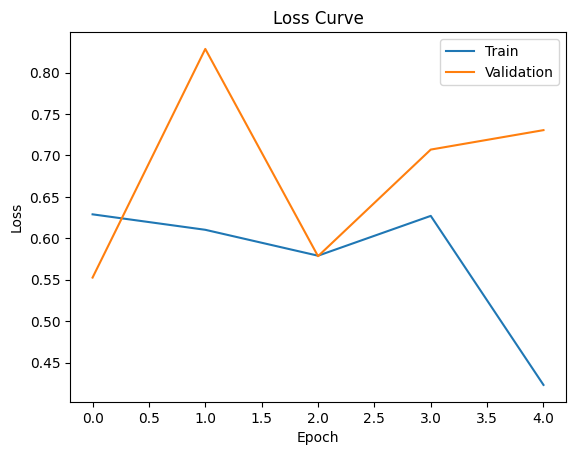

In [98]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

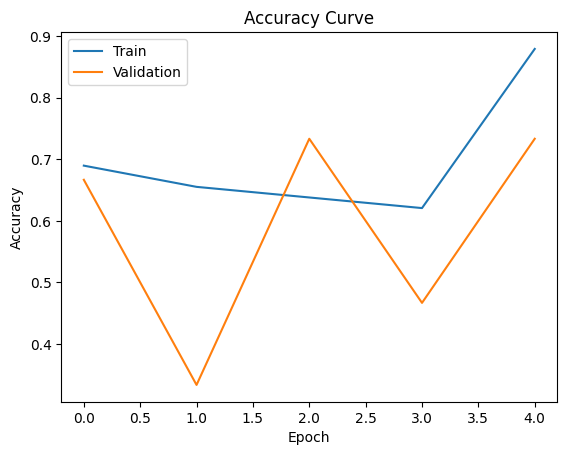

In [99]:
plt.figure()
plt.plot(train_accs)
plt.plot(val_accs)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [100]:
import random
import matplotlib.pyplot as plt
import torch


def show_random_predictions(model, loader, class_names, device):
    model.eval()

    # Convert loader to list of batches
    all_batches = list(loader)

    # Pick random batch
    videos, labels = random.choice(all_batches)

    videos = videos.to(device)

    with torch.no_grad():
        outputs = model(videos)
        preds = torch.argmax(outputs, dim=1)

    videos = videos.cpu()

    batch_size = videos.shape[0]

    for i in range(batch_size):
        plt.figure()

        # Show first frame of video
        frame = videos[i, 0]
        frame = frame.permute(1, 2, 0)

        plt.imshow(frame)
        plt.axis("off")

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]

        color = "green" if true_label == pred_label else "red"

        plt.title(
            f"True: {true_label} | Pred: {pred_label}",
            color=color
        )

        plt.show()

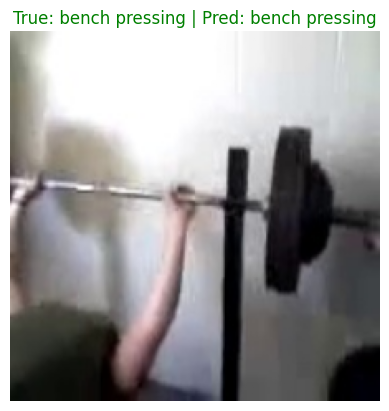

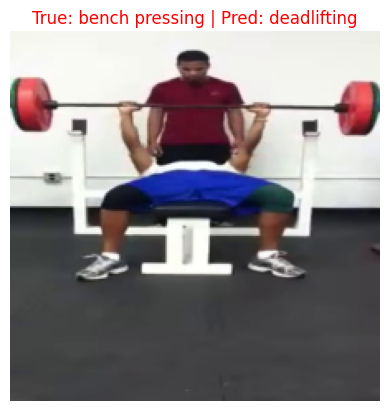

In [103]:
class_names = dataset.classes

show_random_predictions(
    model,
    val_loader,
    class_names,
    device
)